In [1]:
%cd ..

/home/ricka/Git/GitHub/RickArko/kaggle/comp/kcom-predicting-stellar-class


# Feature Engineering — Predicting Stellar Class (S6E6)

### Contents
1. Load raw data
2. Apply feature engineering pipeline
3. Inspect engineered features
4. Validate feature distributions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

from stellar.data import load_data, encode_target
from stellar.features import make_features

train, test = load_data('data/')

## 1. Apply Feature Pipeline

In [3]:
X_train, X_test, y_train = make_features(train, test)

print('X_train shape:', X_train.shape)
print('X_test shape: ', X_test.shape)
print('Columns:', X_train.columns.tolist())

X_train shape: (577347, 12)
X_test shape:  (247435, 12)
Columns: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z']


## 2. Inspect Colour Index Features

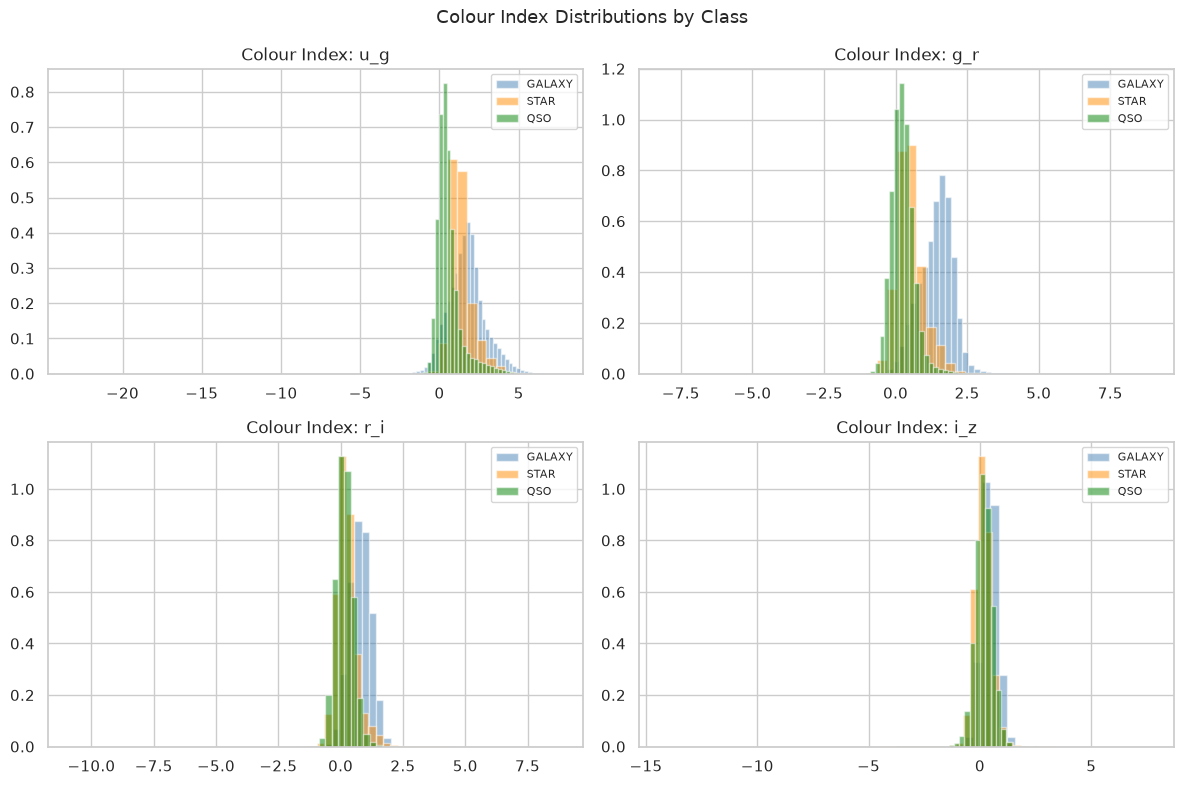

In [4]:
colour_cols = ['u_g', 'g_r', 'r_i', 'i_z']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), colour_cols):
    for cls, color in zip(['GALAXY', 'STAR', 'QSO'], ['steelblue', 'darkorange', 'green']):
        mask = y_train == cls
        ax.hist(X_train.loc[mask, col].dropna(), bins=50, alpha=0.5,
                label=cls, color=color, density=True)
    ax.set_title(f'Colour Index: {col}')
    ax.legend(fontsize=8)
plt.suptitle('Colour Index Distributions by Class', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Encode Target

In [5]:
y_enc, label_map = encode_target(y_train)
print('Label map:', label_map)
print(y_enc.value_counts())

Label map: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}
class
0    377480
1    117143
2     82724
Name: count, dtype: int64


## 4. Feature Importance Preview (Quick Random Forest)

A quick sanity check before full model training.

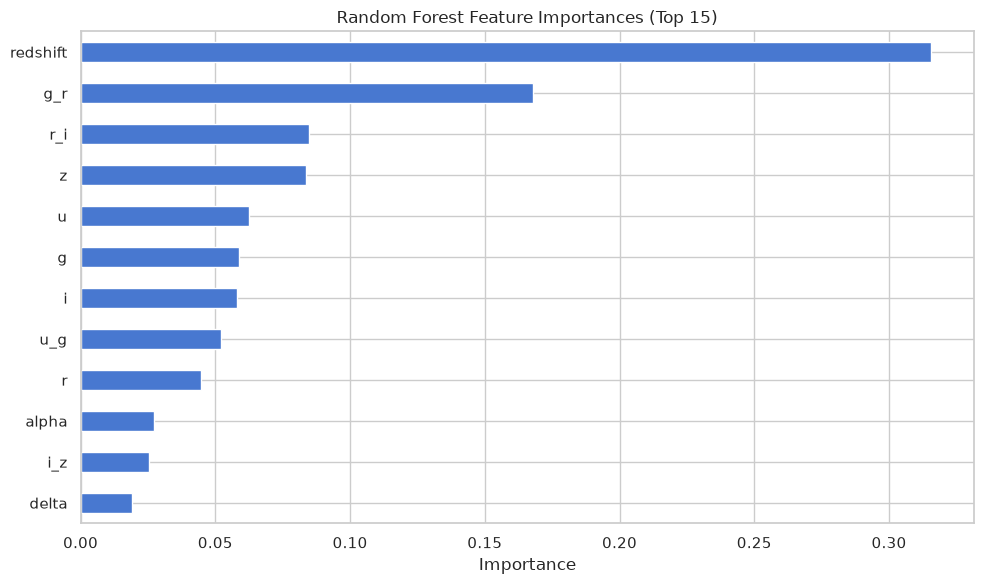

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_tmp = le.fit_transform(y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_tmp)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.head(15).plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Random Forest Feature Importances (Top 15)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()